In [3]:
# Check the first rows of each dataset
customers.head()

,customer_id,first_name,email,city,signup_date
0,1,Customer1,customer1@example.com,Abu Dhabi,2025-09-22 17:14:47.542946
1,2,Customer2,customer2@example.com,Ajman,2025-11-21 17:14:47.542968
2,3,Customer3,customer3@example.com,Abu Dhabi,2026-02-21 17:14:47.542973
3,4,Customer4,customer4@example.com,Sharjah,2025-10-09 17:14:47.542977
4,5,Customer5,customer5@example.com,Dubai,2025-07-22 17:14:47.542982


In [4]:
products.head()

,product_id,product_name,category,price
0,1,Product1,Home,786.16
1,2,Product2,Home,40.62
2,3,Product3,Books,573.02
3,4,Product4,Books,26.58
4,5,Product5,Clothing,260.38


In [5]:
orders.head()

,order_id,customer_id,order_date,status
0,1,25,2026-01-04 17:14:47.555098,completed
1,2,27,2026-02-08 17:14:47.555110,completed
2,3,63,2026-03-25 17:14:47.555115,completed
3,4,93,2026-02-20 17:14:47.555118,cancelled
4,5,81,2025-11-28 17:14:47.555122,pending


In [6]:
order_items.head()

,order_item_id,order_id,product_id,quantity,unit_price,total_price
0,1,1,27,5,216.77,1083.85
1,2,1,29,4,345.84,1383.36
2,3,2,5,2,260.38,520.76
3,4,2,29,3,345.84,1037.52
4,5,2,21,3,463.23,1389.69


## Step 1: Load and Inspect the Data

Before starting the analysis, I inspected the dataset to understand the available columns, number of rows, data types, missing values, and duplicates.

In [7]:
transactions.head()

,transaction_id,order_id,payment_method,payment_status,transaction_date,amount
0,1,1,card,paid,2026-01-04 17:14:47.555098,2467.21
1,2,2,cash,failed,2026-02-08 17:14:47.555110,3263.99
2,3,3,card,refunded,2026-03-25 17:14:47.555115,4431.36
3,4,4,bank_transfer,refunded,2026-02-20 17:14:47.555118,3453.62
4,5,5,cash,refunded,2025-11-28 17:14:47.555122,3625.70


In [2]:
customers = pd.read_csv("../data/raw/customers.csv")
products = pd.read_csv("../data/raw/products.csv")
orders = pd.read_csv("../data/raw/orders.csv")
order_items = pd.read_csv("../data/raw/order_items.csv")
transactions = pd.read_csv("../data/raw/transactions.csv")

In [8]:
print("Customers shape:", customers.shape)
print("Products shape:", products.shape)
print("Orders shape:", orders.shape)
print("Order items shape:", order_items.shape)
print("Transactions shape:", transactions.shape)

Customers shape: (100, 5)
Products shape: (30, 4)
Orders shape: (200, 4)
Order items shape: (496, 6)
Transactions shape: (200, 6)


In [9]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  100 non-null    int64
 1   first_name   100 non-null    str  
 2   email        100 non-null    str  
 3   city         100 non-null    str  
 4   signup_date  100 non-null    str  
dtypes: int64(1), str(4)
memory usage: 10.3 KB


In [10]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    30 non-null     int64  
 1   product_name  30 non-null     str    
 2   category      30 non-null     str    
 3   price         30 non-null     float64
dtypes: float64(1), int64(1), str(2)
memory usage: 1.5 KB


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   order_id     200 non-null    int64
 1   customer_id  200 non-null    int64
 2   order_date   200 non-null    str  
 3   status       200 non-null    str  
dtypes: int64(2), str(2)
memory usage: 13.1 KB


# Week 2 Day 5 — Data Storytelling & Mini Analytics Project

## Project Question

Which product categories generate the most revenue, and what business insights can we learn from them?

## Goal

The goal of this mini analytics project is to analyze the e-commerce dataset, create summary visuals, and explain the findings using clear business insights.

## Data Flow

CSV files → Python/Pandas → Analysis → Visualizations → Insights → Business Recommendations

In [12]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  496 non-null    int64  
 1   order_id       496 non-null    int64  
 2   product_id     496 non-null    int64  
 3   quantity       496 non-null    int64  
 4   unit_price     496 non-null    float64
 5   total_price    496 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 23.4 KB


In [13]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    200 non-null    int64  
 1   order_id          200 non-null    int64  
 2   payment_method    200 non-null    str    
 3   payment_status    200 non-null    str    
 4   transaction_date  200 non-null    str    
 5   amount            200 non-null    float64
dtypes: float64(1), int64(2), str(3)
memory usage: 17.3 KB


In [14]:
print("Missing values in customers:")
print(customers.isnull().sum())

print("\nMissing values in products:")
print(products.isnull().sum())

print("\nMissing values in orders:")
print(orders.isnull().sum())

print("\nMissing values in order_items:")
print(order_items.isnull().sum())

print("\nMissing values in transactions:")
print(transactions.isnull().sum())

Missing values in customers:
customer_id    0
first_name     0
email          0
city           0
signup_date    0
dtype: int64

Missing values in products:
product_id      0
product_name    0
category        0
price           0
dtype: int64

Missing values in orders:
order_id       0
customer_id    0
order_date     0
status         0
dtype: int64

Missing values in order_items:
order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
total_price      0
dtype: int64

Missing values in transactions:
transaction_id      0
order_id            0
payment_method      0
payment_status      0
transaction_date    0
amount              0
dtype: int64


In [15]:
print("Duplicate rows in customers:", customers.duplicated().sum())
print("Duplicate rows in products:", products.duplicated().sum())
print("Duplicate rows in orders:", orders.duplicated().sum())
print("Duplicate rows in order_items:", order_items.duplicated().sum())
print("Duplicate rows in transactions:", transactions.duplicated().sum())

Duplicate rows in customers: 0
Duplicate rows in products: 0
Duplicate rows in orders: 0
Duplicate rows in order_items: 0
Duplicate rows in transactions: 0


### Data Quality Check Summary

After inspecting the dataset, no missing values or duplicate rows were found.  
This means the data is ready for analysis, but some columns may still need type conversion before creating calculations and visuals.

## Step 2: Prepare Data for Analysis

To analyze revenue by product category, I merged the order_items table with the products table using product_id. This connects each sold item with its product category.

In [17]:
# Merge order items with products to get product category information
sales_data = order_items.merge(
    products,
    on="product_id",
    how="left"
)

sales_data.head()

,order_item_id,order_id,product_id,quantity,unit_price,total_price,product_name,category,price
0,1,1,27,5,216.77,1083.85,Product27,Books,216.77
1,2,1,29,4,345.84,1383.36,Product29,Books,345.84
2,3,2,5,2,260.38,520.76,Product5,Clothing,260.38
3,4,2,29,3,345.84,1037.52,Product29,Books,345.84
4,5,2,21,3,463.23,1389.69,Product21,Clothing,463.23


## Step 3: Analyze Revenue by Product Category

After merging the sales and product data, I grouped the data by product category and calculated the total revenue for each category.

In [18]:
revenue_by_category = (
    sales_data
    .groupby("category")["total_price"]
    .sum()
    .reset_index()
    .sort_values(by="total_price", ascending=False)
)

revenue_by_category

,category,total_price
0,Books,238604.84
2,Electronics,190247.20
3,Home,172266.55
1,Clothing,150662.66


In [19]:
revenue_by_category = revenue_by_category.rename(
    columns={"total_price": "total_revenue"}
)

revenue_by_category

,category,total_revenue
0,Books,238604.84
2,Electronics,190247.20
3,Home,172266.55
1,Clothing,150662.66


## Step 4: Visualize Revenue by Category

A bar chart was created to compare total revenue across product categories. This makes it easier to identify the strongest and weakest categories.

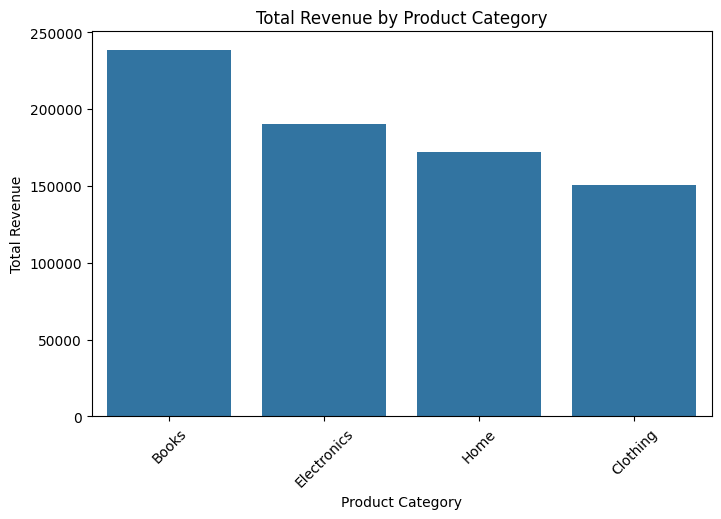

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=revenue_by_category,
    x="category",
    y="total_revenue"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

### Insight 1: Books Generated the Highest Revenue

The Books category generated the highest total revenue with 238,604.84.  
Electronics came second with 190,247.20, followed by Home and Clothing.

This shows that Books is the strongest revenue-generating category in the dataset.  
The business may consider increasing promotions, inventory, or recommendations for this category because it contributes the most revenue.

In [21]:
total_revenue = revenue_by_category["total_revenue"].sum()

revenue_by_category["revenue_percentage"] = (
    revenue_by_category["total_revenue"] / total_revenue * 100
).round(2)

revenue_by_category

,category,total_revenue,revenue_percentage
0,Books,238604.84,31.74
2,Electronics,190247.20,25.31
3,Home,172266.55,22.91
1,Clothing,150662.66,20.04


## Step 5: Analyze Quantity Sold by Category

To understand whether high revenue comes from high sales volume, I also calculated the total quantity sold for each product category.

In [22]:
quantity_by_category = (
    sales_data
    .groupby("category")["quantity"]
    .sum()
    .reset_index()
    .sort_values(by="quantity", ascending=False)
)

quantity_by_category

,category,quantity
0,Books,509
3,Home,400
2,Electronics,317
1,Clothing,287


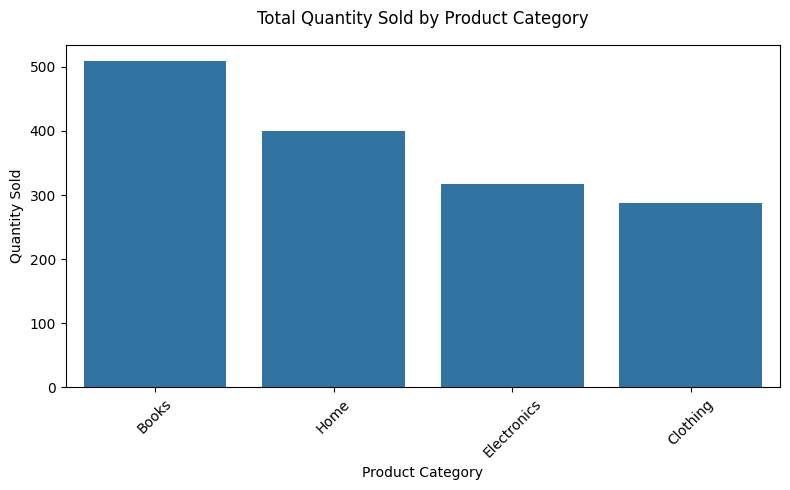

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=quantity_by_category,
    x="category",
    y="quantity"
)

plt.title("Total Quantity Sold by Product Category", pad=15)
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight 2: Books Also Had the Highest Quantity Sold

The Books category had the highest quantity sold with 509 units.  
This supports the revenue finding because Books was also the top category by total revenue.

This means the Books category is strong because it performs well in both sales volume and revenue.  
The business can treat Books as a high-demand category and make sure inventory levels are maintained.

## Step 6: Analyze Average Revenue Per Item

To better understand category performance, I calculated the average revenue per item sold. This helps show whether revenue is driven by high sales volume or higher item value.

In [24]:
category_summary = revenue_by_category.merge(
    quantity_by_category,
    on="category",
    how="left"
)

category_summary["avg_revenue_per_item"] = (
    category_summary["total_revenue"] / category_summary["quantity"]
).round(2)

category_summary = category_summary.sort_values(
    by="avg_revenue_per_item",
    ascending=False
)

category_summary

,category,total_revenue,revenue_percentage,quantity,avg_revenue_per_item
1,Electronics,190247.20,25.31,317,600.15
3,Clothing,150662.66,20.04,287,524.96
0,Books,238604.84,31.74,509,468.77
2,Home,172266.55,22.91,400,430.67


### Insight 3: Electronics Has the Highest Average Revenue Per Item

Although Books generated the highest total revenue and quantity sold, Electronics had the highest average revenue per item at 600.15.

This suggests that Electronics products may have higher item value compared to other categories.  
The business can use this insight by promoting Electronics products to increase revenue per sale, while still maintaining Books as the strongest high-volume category.

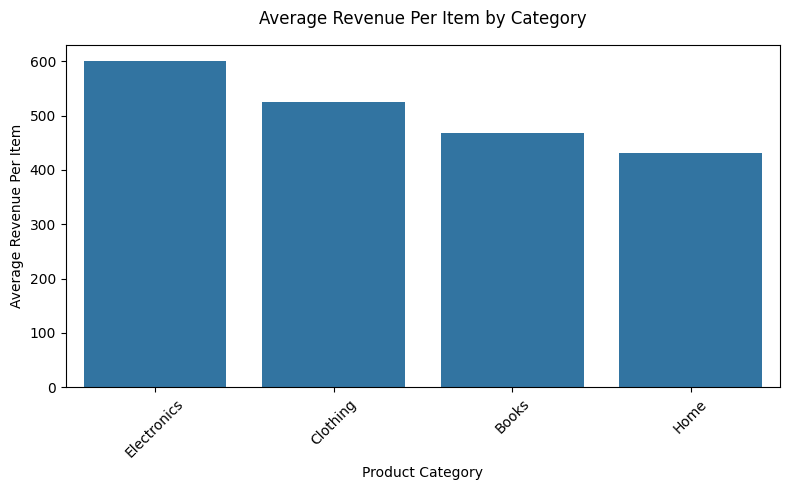

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_summary,
    x="category",
    y="avg_revenue_per_item"
)

plt.title("Average Revenue Per Item by Category", pad=15)
plt.xlabel("Product Category")
plt.ylabel("Average Revenue Per Item")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Final Business Summary

The analysis showed that Books is the strongest product category in the dataset.  
Books generated the highest total revenue with 238,604.84, contributing 31.74% of total revenue.  
It also had the highest quantity sold with 509 units, which shows strong customer demand.

Electronics ranked second in total revenue, but it had the highest average revenue per item at 600.15.  
This means Electronics may be a high-value category, even though it sold fewer units than Books and Home.

Clothing had the lowest total revenue and the lowest quantity sold.  
This may indicate weaker demand compared to the other categories.

## Business Recommendations

Based on the analysis, the business should:

1. Maintain strong inventory for Books because it has the highest sales volume and total revenue.
2. Promote Electronics because it has the highest average revenue per item and can increase revenue per sale.
3. Review Clothing performance to understand why it has the lowest revenue and quantity sold.
4. Use category-level performance to guide marketing campaigns, stock planning, and product recommendations.

## Reflection on SQL and MongoDB Integration

This mini project helped connect the previous Week 1 and Week 2 tasks.

In SQL, I learned how to use joins, grouping, and aggregation to answer business questions from relational tables.  
In MongoDB, I learned how aggregation pipelines can also be used to summarize and analyze data, especially with stages like `$match`, `$lookup`, `$group`, and `$sort`.

In this notebook, I used pandas to perform similar ideas:
- `merge()` worked like a SQL join.
- `groupby()` worked like SQL GROUP BY or MongoDB `$group`.
- sorting results helped identify the strongest and weakest categories.

The main lesson is that SQL, MongoDB, and pandas can all be used to analyze data, but the syntax is different.  
The business goal stays the same: use data to find insights and support decisions.

## What I Learned

In this task, I learned how to turn analysis results into a clear business story.  
I practiced loading data, inspecting data quality, merging related tables, calculating revenue metrics, creating charts, and writing insights.

I also learned that charts alone are not enough.  
A good analytics project should explain what the numbers mean and what action the business can take.

This task connected the full data flow:
raw data → cleaning/checking → analysis → visualization → insight → recommendation.